# Análise de Eficiência de Cobrança

## 1. Configuração de Ambiente

### 1.1 - Intalação e importação

In [1]:
!pip install google-cloud-bigquery --upgrade -q

In [2]:
# Bibliotecas
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Autorizar acesso
auth.authenticate_user()
print('Autenticado com sucesso')

Autenticado com sucesso


### 1.2 - Fonte de dados   

In [4]:
id_projeto = 'projetoanalisecobranca'
cliente = bigquery.Client(project=id_projeto)

consulta = """
  SELECT *
  FROM `projetoanalisecobranca.analise_cobranca.vw_dataset_final`;
"""

df = cliente.query(consulta).to_dataframe()

print(df.head().to_string())

  id_cliente  limite_credito  genero  nivel_escolaridade  estado_civil  idade  atraso_mes_0  atraso_mes_2  atraso_mes_3  atraso_mes_4  atraso_mes_5  atraso_mes_6  valor_emitido_1  valor_emitido_2  valor_emitido_3  valor_emitido_4  valor_emitido_5  valor_emitido_6  valor_pago_1  valor_pago_2  valor_pago_3  valor_pago_4  valor_pago_5  valor_pago_6  valor_total_faturado  valor_total_pago  percentual_pago  saldo_liquido  nivel_eficiencia_pagamento  atraso_recente  total_meses_atraso  atraso_maximo  cliente_pontual
0      27502         80000.0       1                   6             1     54             0             0             0             0             0             0          61454.0          61808.0          62290.0          29296.0          26210.0          17643.0        2545.0        2208.0        1336.0        2232.0         542.0         348.0              258701.0            9211.0             3.56       249490.0                           1               0                   0 

## 2. EDA

### 2.1 - Informações Gerais

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2787 entries, 0 to 2786
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  2787 non-null   object 
 1   limite_credito              2787 non-null   float64
 2   genero                      2787 non-null   Int64  
 3   nivel_escolaridade          2787 non-null   Int64  
 4   estado_civil                2787 non-null   Int64  
 5   idade                       2787 non-null   Int64  
 6   atraso_mes_0                2787 non-null   Int64  
 7   atraso_mes_2                2787 non-null   Int64  
 8   atraso_mes_3                2787 non-null   Int64  
 9   atraso_mes_4                2787 non-null   Int64  
 10  atraso_mes_5                2787 non-null   Int64  
 11  atraso_mes_6                2787 non-null   Int64  
 12  valor_emitido_1             2787 non-null   float64
 13  valor_emitido_2             2787 

In [6]:
df.describe()

,limite_credito,genero,nivel_escolaridade,estado_civil,idade,atraso_mes_0,atraso_mes_2,atraso_mes_3,atraso_mes_4,atraso_mes_5,...,valor_pago_6,valor_total_faturado,valor_total_pago,percentual_pago,saldo_liquido,nivel_eficiencia_pagamento,atraso_recente,total_meses_atraso,atraso_maximo,cliente_pontual
count,2787.000000,2787.0,2787.0,2787.0,2787.0,2787.0,2787.0,2787.0,2787.0,2787.0,...,2787.000000,2.787000e+03,2.787000e+03,2701.000000,2.787000e+03,2787.0,2787.0,2787.0,2787.0,2787.0
mean,160660.208109,1.610334,1.85253,1.560818,35.10226,0.033369,-0.068174,-0.086832,-0.126659,-0.16864,...,5281.688554,2.891175e+05,3.221212e+04,35.428601,2.569054e+05,1.068174,0.218156,0.858988,0.506279,0.658414
std,124224.493450,0.487762,0.77153,0.52176,9.132703,1.097523,1.164047,1.16804,1.162388,1.144722,...,16847.872173,3.745565e+05,6.334235e+04,74.428529,3.592778e+05,0.353958,0.413068,1.585286,1.324115,0.474327
min,10000.000000,1.0,0.0,0.0,21.0,-2.0,-2.0,-2.0,-2.0,-2.0,...,0.000000,0.000000e+00,0.000000e+00,0.000000,-3.863420e+05,0.0,0.0,0.0,-2.0,0.0
25%,50000.000000,1.0,1.0,1.0,28.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,220.000000,4.045050e+04,7.284000e+03,4.210000,1.060200e+04,1.0,0.0,0.0,0.0,0.0
50%,130000.000000,2.0,2.0,2.0,33.0,0.0,0.0,0.0,0.0,0.0,...,1700.000000,1.530340e+05,1.512000e+04,8.220000,1.212790e+05,1.0,0.0,0.0,0.0,1.0
75%,230000.000000,2.0,2.0,2.0,41.0,0.0,0.0,0.0,0.0,0.0,...,4154.500000,3.892455e+05,3.397500e+04,46.840000,3.515875e+05,1.0,0.0,1.0,2.0,1.0
max,800000.000000,2.0,6.0,3.0,69.0,8.0,7.0,7.0,8.0,7.0,...,403500.000000,2.822922e+06,1.896316e+06,1548.820000,2.723462e+06,2.0,1.0,6.0,8.0,1.0


### 2.2 - Distribuição do limite de crédito

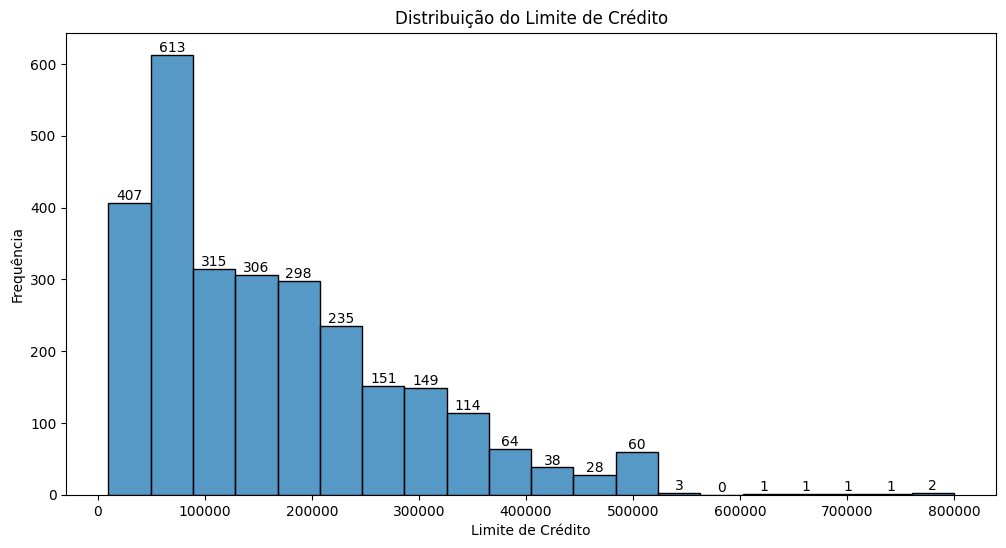

In [7]:
plt.figure(figsize=(12, 6))
ax = sns.histplot(df['limite_credito'], bins=20, edgecolor='black')
ax.bar_label(ax.containers[0])
plt.xlabel('Limite de Crédito')
plt.ylabel('Frequência')
plt.title('Distribuição do Limite de Crédito')
plt.show()

A maior parte dos clientes possui limite de crédito inferior a 100 mil, indicando concentração da base em faixas de crédito mais baixas




### 2.3  Perfil demográfico dos clientes

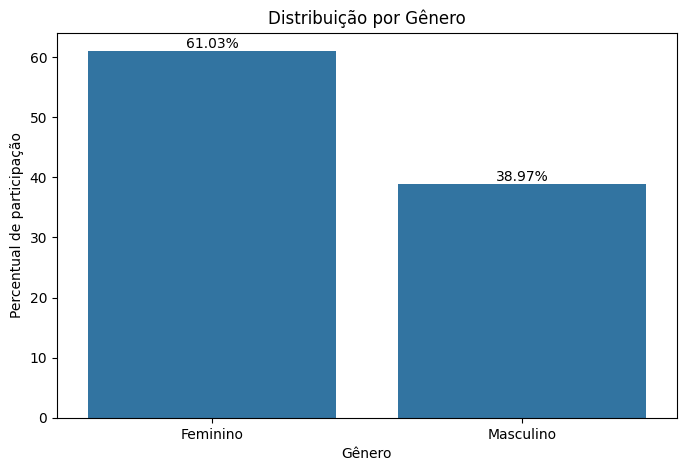

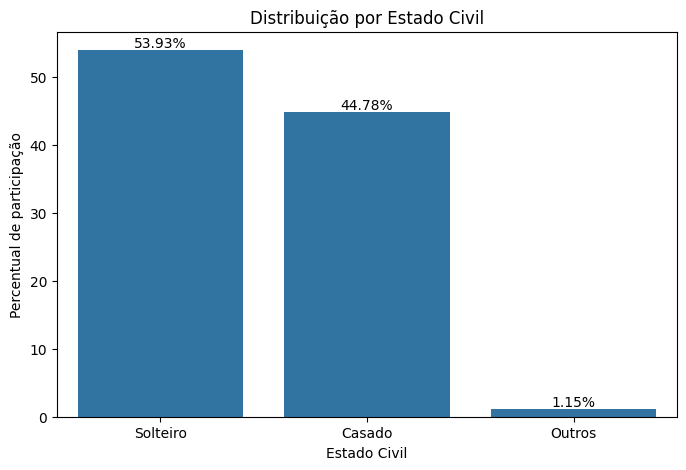

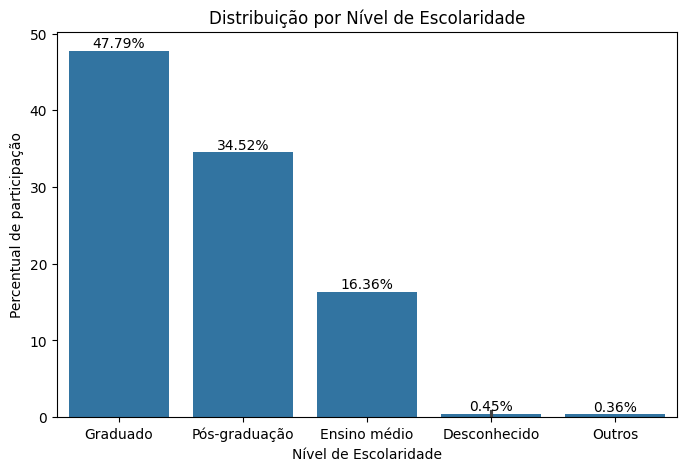

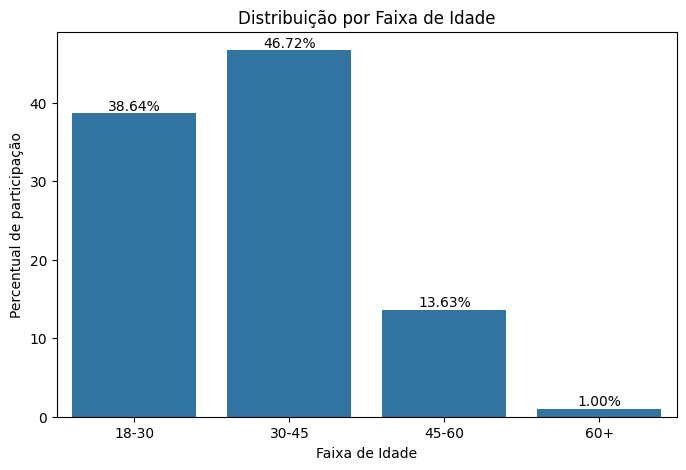

In [8]:
df['faixa_idade'] = pd.cut(
    df['idade'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '30-45', '45-60', '60+']
)

colunas = ['genero', 'estado_civil', 'nivel_escolaridade', 'faixa_idade']

nomes_colunas = {
    'genero': 'Gênero',
    'estado_civil': 'Estado Civil',
    'nivel_escolaridade': 'Nível de Escolaridade',
    'faixa_idade': 'Faixa de Idade'
}



mapeamentos = {
    'genero': {
        1: 'Masculino',
        2: 'Feminino'
    },
    'estado_civil': {
        1: 'Casado',
        2: 'Solteiro',
        3: 'Outros'
    },
    'nivel_escolaridade': {
        1: 'Pós-graduação',
        2: 'Graduado',
        3: 'Ensino médio',
        4: 'Outros',
        5: 'Desconhecido',
        6: 'Desconhecido'
    }
}

for coluna in colunas:
  dados = df[coluna].value_counts().reset_index()
  dados.columns = [coluna, 'frequencia']
  dados['perct_participacao'] = (dados['frequencia'] / dados['frequencia'].sum()*100).round(2)

  if coluna in mapeamentos:
    dados[coluna] = dados[coluna].map(mapeamentos[coluna])

  plt.figure(figsize=(8, 5))
  ax = sns.barplot(x=coluna, y='perct_participacao', data=dados)
  ax.bar_label(ax.containers[0], fmt='%.2f%%')
  plt.xlabel(nomes_colunas[coluna])
  plt.ylabel('Percentual de participação')
  plt.title(f'Distribuição por {nomes_colunas[coluna]}')
  plt.show()

A base é predominantemente feminina, composta por clientes solteiros, com idade abaixo de 45 anos e com nível de escolaridade superior, indicando um perfil mais jovem e com maior nível educacional.

### 2.4 - Distribuição do percentual de pagamento

Text(0.5, 0, 'Percentual de Pago')

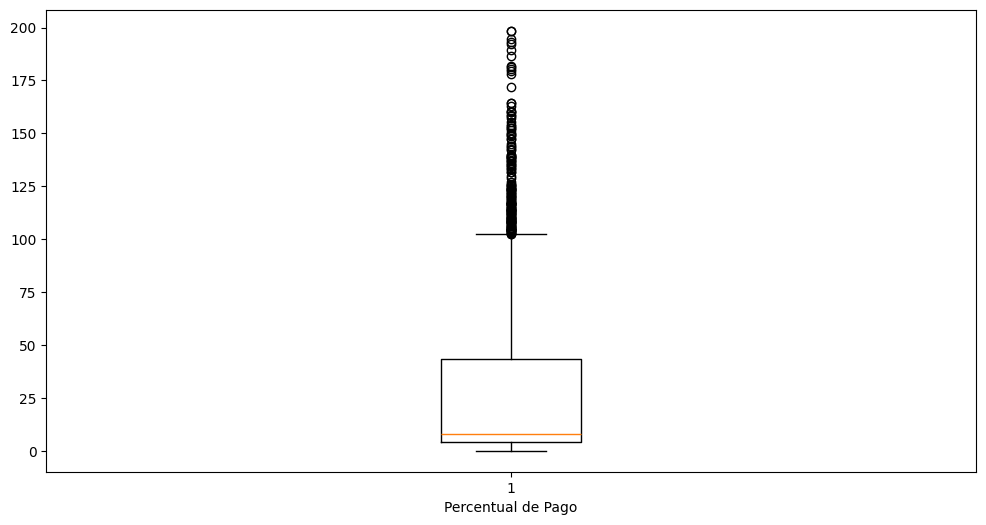

In [9]:
df_filtrado = df[df['percentual_pago'] <= 200]

plt.figure(figsize=(12,6))
plt.boxplot(df_filtrado ['percentual_pago'], vert=True)
plt.xlabel('Percentual de Pago')



Observa-se que a maior parte dos clientes apresenta baixo percentual de pagamento, com mediana próxima a 10%, indicando pagamento predominantemente parcial das faturas. Além disso, há presença significativa de valores acima de 100%, sugerindo quitação de dívidas acumuladas por parte de alguns clientes.

### 2.5 - Relação entre faturado e pago

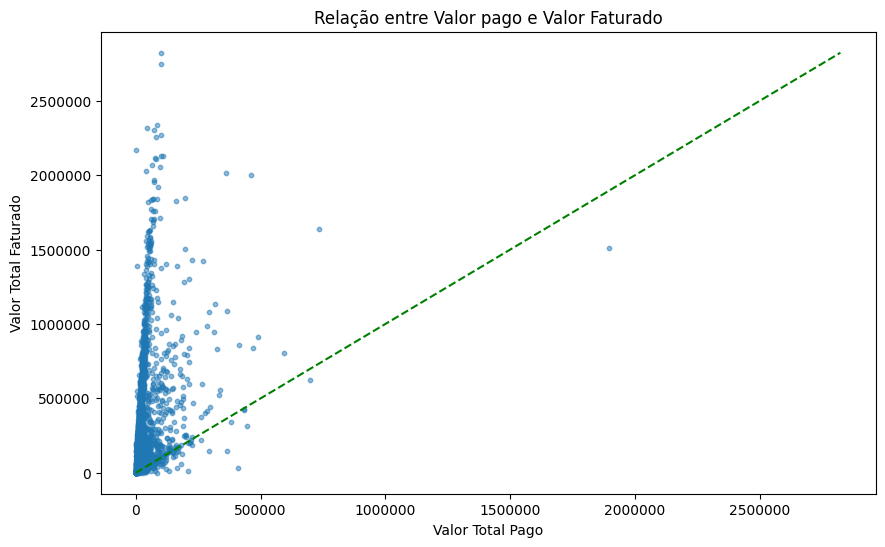

In [10]:
max_val = max(df['valor_total_faturado'].max(), df['valor_total_pago'].max())

plt.figure(figsize=(10, 6))
plt.scatter(df['valor_total_pago'],  df['valor_total_faturado'], s=10, alpha=0.5)
plt.plot([0, max_val], [0, max_val], color='green', linestyle='--')
plt.ticklabel_format(style='plain', axis='both')
plt.xlabel('Valor Total Pago')
plt.ylabel('Valor Total Faturado')
plt.title('Relação entre Valor pago e Valor Faturado')
plt.show()

O gráfico mostra que a maioria dos clientes paga menos do que foi faturado, indicando acúmulo de dívida ao longo do tempo. Além disso, há uma concentração de clientes com baixos níveis de pagamento, o que reforça um padrão de pagamento parcial.

### 2.6 - Distribuição de atraso recente

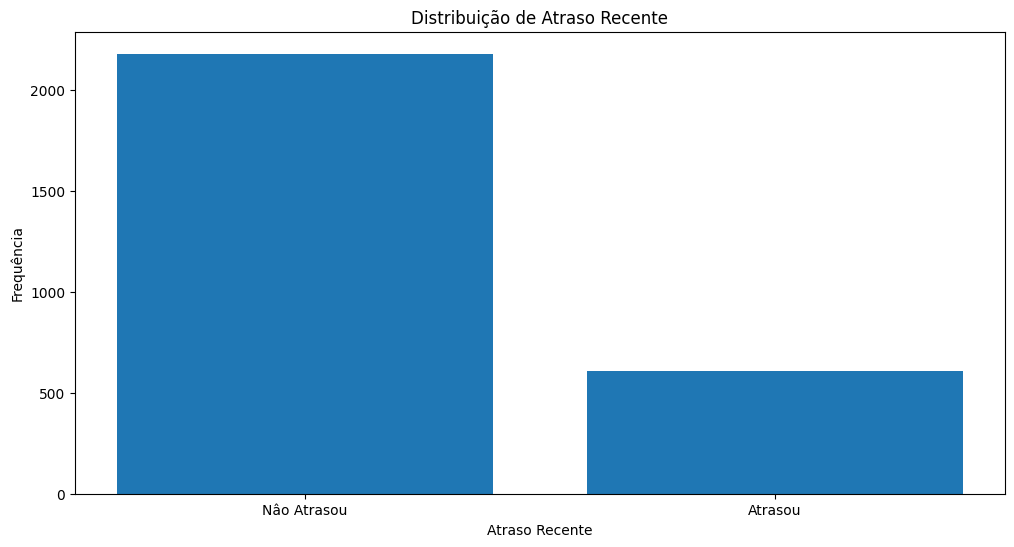

In [11]:
dados = df['atraso_recente'].value_counts().reset_index()
dados.columns = ['atraso_recente', 'frequencia']


dados['atraso_recente_map'] = dados['atraso_recente'].map({
    0: 'Nâo Atrasou',
    1: 'Atrasou'
})

plt.figure(figsize=(12,6))
plt.bar(dados['atraso_recente_map'], dados['frequencia'])
plt.xlabel('Atraso Recente')
plt.ylabel('Frequência')
plt.title('Distribuição de Atraso Recente')
plt.show()


Mesmo sendo um grupo menor, quem teve atraso recente merece atenção, porque tem mais chance de não pagar no futuro.

### 2.7 - Distribuição do total de meses em atraso

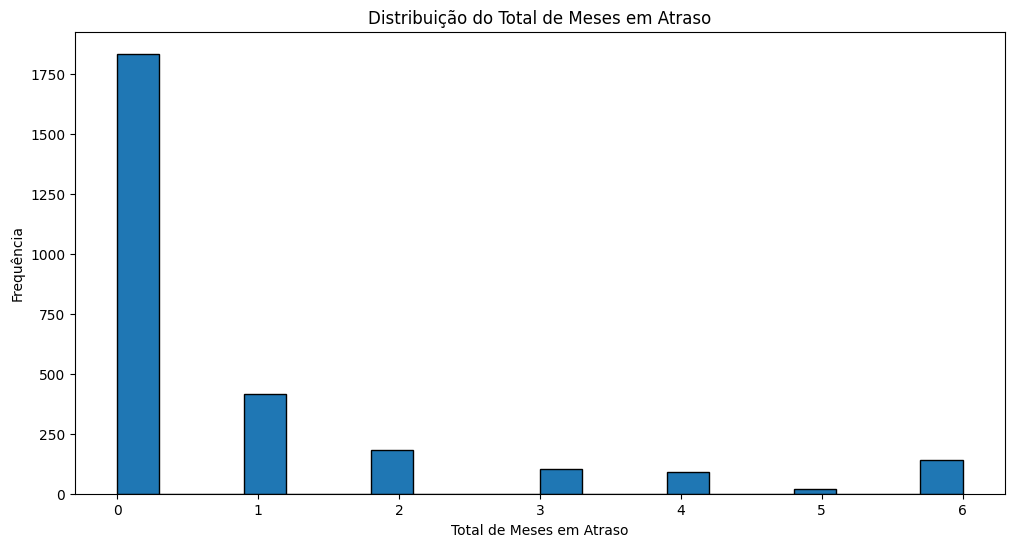

In [12]:
plt.figure(figsize=(12,6))
plt.hist(df['total_meses_atraso'], bins=20, edgecolor='black')
plt.title('Distribuição do Total de Meses em Atraso')
plt.xlabel('Total de Meses em Atraso')
plt.ylabel('Frequência')
plt.show()

A maioria dos clientes fazem os pagamentos em dia, mas realizam pagamentos parciais, o que leva ao acúmulo de dívida ao longo do tempo.

### 2.8 - Relação entre Atraso e Eficiência de Pagamento

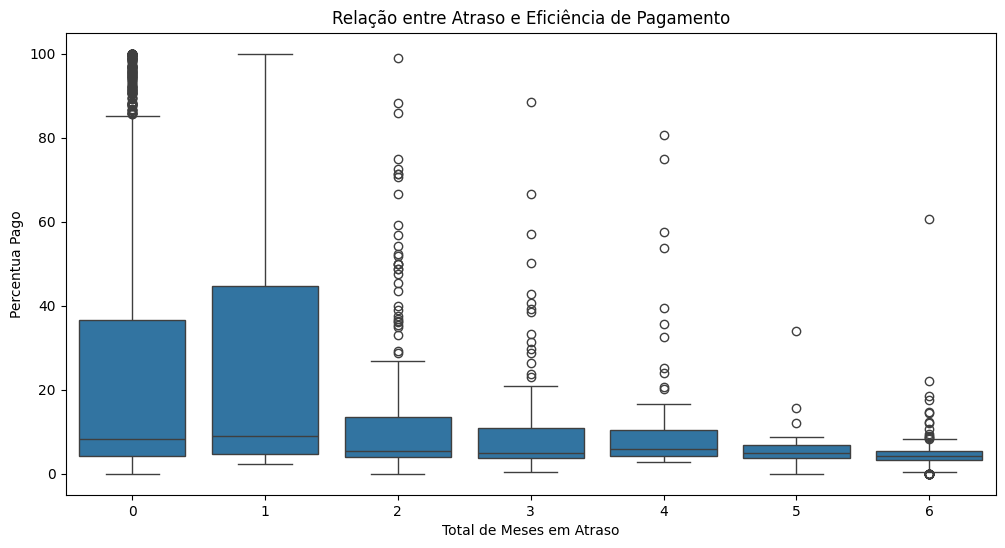

In [13]:
limite = df['percentual_pago'].quantile(0.90)
df_filtrado = df[df['percentual_pago'] <= limite]


plt.figure(figsize=(12,6))
sns.boxplot(
    x = 'total_meses_atraso',
    y = 'percentual_pago',
    data = df_filtrado
)
plt.title('Relação entre Atraso e Eficiência de Pagamento')
plt.xlabel('Total de Meses em Atraso')
plt.ylabel('Percentua Pago')
plt.show()



De forma geral, observa-se que quanto maior o número de meses em atraso, menor tende a ser o percentual de pagamento. Como exceção, clientes com 1 mês de atraso apresentam, em média, um percentual de pagamento ligeiramente superior.

### 2.9 - Correlação entre variáveis financeiras

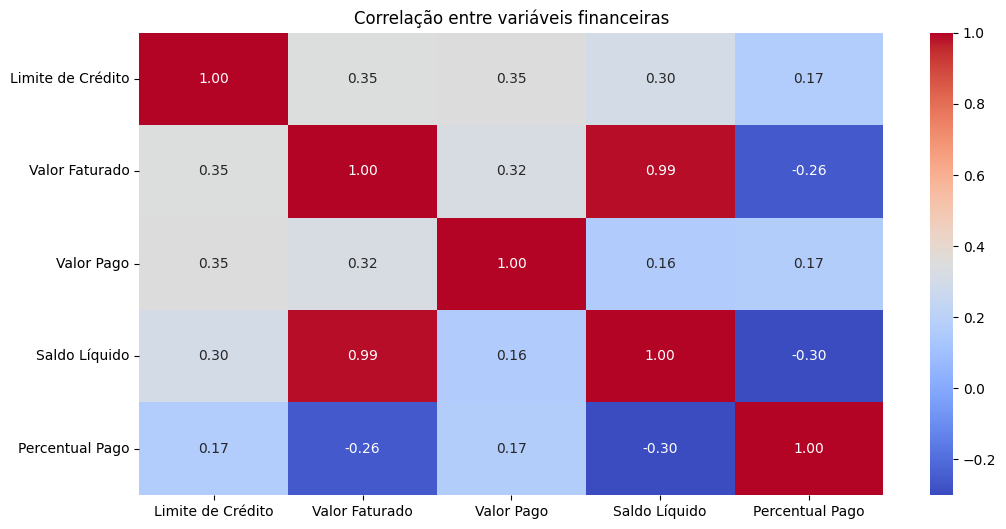

In [45]:
df_filtrado = df[['limite_credito', 'valor_total_faturado','valor_total_pago', 'saldo_liquido', 'percentual_pago']]

colunas = {
    'limite_credito': 'Limite de Crédito',
    'valor_total_faturado': 'Valor Faturado',
    'valor_total_pago': 'Valor Pago',
    'saldo_liquido': 'Saldo Líquido',
    'percentual_pago': 'Percentual Pago'
}

df_filtrado = df_filtrado.rename(columns=colunas)

corr = df_filtrado.corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlação entre variáveis financeiras')
plt.show()

A análise de correlação entre variáveis financeiras indica que clientes com maior limite de crédito tendem a apresentar maior volume de faturamento e pagamento. Observa-se também uma correlação negativa entre percentual de pagamento e saldo devedor, indicando que maiores níveis de pagamento estão associados à redução da dívida.

## 3 - Conclusões

A análise dos dados mostra que, embora a maioria dos clientes não esteja em atraso, há predominância de pagamentos parciais, o que contribui para o acúmulo de dívida ao longo do tempo.

Observou-se que clientes com maior limite de crédito tendem a apresentar maior volume de faturamento e pagamento, indicando maior movimentação financeira. No entanto, o percentual de pagamento apresenta relação inversa com o saldo devedor, ou seja, quanto menor o percentual pago, maior tende a ser a dívida acumulada.

Além disso, clientes com maior número de meses em atraso tendem a apresentar menor percentual de pagamento, reforçando a relação entre atraso e aumento do risco de inadimplência.

De forma geral, os resultados indicam que o principal risco não está apenas no atraso, mas também no comportamento de pagamento parcial, que pode levar ao endividamento progressivo dos clientes ao longo do tempo.

Como possível ação, recomenda-se que estratégias de cobrança considerem não apenas clientes em atraso, mas também aqueles que realizam pagamentos mínimos recorrentes, buscando reduzir o risco de inadimplência futura.